# GREAC — sweep k × janela × threshold

Lê o `parameter_sweep_<organismo>.csv` gravado pelo `fit-parameters` em `GREAC/output-sweep-<organismo>/`
(uma linha por repetição × combinação) e agrega média ± desvio padrão sobre as repetições.
Cada repetição é um split train/test independente, e é daí que vem o desvio.

**Parâmetros** (célula seguinte, marcada `parameters`):

- `ORGANISM` — sufixo do diretório `output-sweep-*` (a lista disponível é impressa ao carregar)
- `MIN_COVERAGE` — fração mínima do conjunto de teste que a combinação precisa classificar para entrar no ranking
- `TOP_N` — quantas combinações mostrar no ranking e na distribuição por repetição
- `WINDOWS_INCLUDE` / `WINDOWS_EXCLUDE` — restringe as janelas consideradas (vazio = todas). O filtro entra
  antes de qualquer agregação, então ranking, empates, heatmaps, tempos e o `summary.csv` saem todos só com
  as janelas escolhidas

Também corre sem abrir o Jupyter, via papermill:

```bash
papermill greac_sweep.ipynb out.ipynb -p ORGANISM hiv
```

**Duas armadilhas destes dados:**
- **Cobertura.** O GREAC descarta as sequências de teste sem nenhum k-mer nas regiões selecionadas e calcula o F1
  só sobre as restantes. Uma combinação pode ter F1 alto classificando uma fração pequena do teste. A cobertura é
  `n_test` dividido pelo maior `n_test` da mesma repetição (o mesmo split). É um limite inferior do teste real:
  se nenhuma combinação classificar tudo, a cobertura fica superestimada.
- **Buracos na grade.** A janela em bases é `ceil(menor sequência × window)`, e k maior que a janela não roda.
  Essas combinações não têm linha no CSV e aparecem nos heatmaps como *não executada*, não como zero.

In [6]:
ORGANISM = "hiv"
MIN_COVERAGE = 0.95
TOP_N = 10
WINDOWS_INCLUDE = []   # [] = todas; ex.: [0.0025, 0.003] considera só essas
WINDOWS_EXCLUDE = []   # ex.: [0.0015] descarta essa janela

In [7]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SWEEP_ROOT = os.path.join("..", "GREAC")
SWEEPS = {
    os.path.basename(d).removeprefix("output-sweep-"): d
    for d in sorted(glob.glob(os.path.join(SWEEP_ROOT, "output-sweep-*")))
}
if ORGANISM not in SWEEPS:
    raise ValueError(f"ORGANISM {ORGANISM!r} sem sweep em {SWEEP_ROOT}; disponíveis: {sorted(SWEEPS)}")

# Shards do sweep corrente: o arquivo base e um .part-<run-id> por job paralelo.
# Os arquivados (parameter_sweep_<org>_<timestamp>.csv, ou arquivados/) são
# experimentos anteriores e não entram na média.
CSV_PATHS = [p for p in (
    [os.path.join(SWEEPS[ORGANISM], f"parameter_sweep_{ORGANISM}.csv")]
    + sorted(glob.glob(os.path.join(SWEEPS[ORGANISM], f"parameter_sweep_{ORGANISM}.part-*.csv")))
) if os.path.exists(p)]
if not CSV_PATHS:
    raise FileNotFoundError(f"nenhum parameter_sweep_{ORGANISM}*.csv em {SWEEPS[ORGANISM]}")
FIG_DIR = os.path.join("figs", "greac", ORGANISM)
os.makedirs(FIG_DIR, exist_ok=True)
TITLE = f"GREAC · {ORGANISM}"
print("sweeps disponíveis:", sorted(SWEEPS))

sweeps disponíveis: ['hbv', 'hiv', 'monkeypox']


## Estilo

In [8]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # mesma ordem fixa do kmer_sweep_runlogs.ipynb
ACCENT = SERIES[0]
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#a3a29d", "#e3e2dd", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6, "font.size": 10, "figure.dpi": 120,
})

# A janela é ordinal: um só tom, do claro ao escuro, e não cores categóricas.
# Começa em 0.45 da rampa para a janela menor não sumir no fundo.
SEQ = LinearSegmentedColormap.from_list("seq", ["#e4eefb", ACCENT, "#0d2f5c"])


def window_colors(windows):
    windows = sorted(windows)
    if len(windows) == 1:
        return {windows[0]: ACCENT}
    return {w: SEQ(0.45 + 0.55 * i / (len(windows) - 1)) for i, w in enumerate(windows)}


def mean_band(ax, x, mean, std, color, label=None):
    """Linha da média com banda de ±1 desvio padrão (sem banda quando n=1)."""
    std = std.fillna(0)
    ax.fill_between(x, (mean - std).clip(lower=0), (mean + std).clip(upper=1),
                    color=color, alpha=0.15, linewidth=0)
    ax.plot(x, mean, marker="o", color=color, label=label,
            markeredgecolor=SURFACE, markeredgewidth=2)


def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight")

## Leitura dos dados

Uma linha por (repetição, janela, threshold, k), juntando os shards: jobs paralelos gravam cada um o seu
`parameter_sweep_<org>.part-<run-id>.csv`. A última repetição de cada job pode estar incompleta se o sweep ainda
estiver rodando ou tiver sido cortado; ela entra na média com o que tiver, e o `n` de cada combinação mostra
quantas repetições a sustentam.

In [9]:
raw = pd.concat([pd.read_csv(p).assign(shard=os.path.basename(p)) for p in CSV_PATHS],
                ignore_index=True)
raw = raw.drop_duplicates(subset=["rep", "window", "threshold", "kmer"], keep="last")

# Window e threshold vêm de Float32/Float16 no Julia: arredonda para agrupar sem
# criar "0.0025" e "0.0025000002" como janelas diferentes
raw["window"] = raw["window"].round(6)
raw["threshold"] = raw["threshold"].round(3)
raw["train_time"] = raw["extract_time"] + raw["fit_time"]
raw["coverage"] = raw["n_test"] / raw.groupby("rep")["n_test"].transform("max")

# Filtro de janelas antes de qualquer agregação: tudo daqui para baixo (ranking,
# heatmaps, tempos, summary) passa a valer só para as janelas escolhidas
TODAS_JANELAS = sorted(raw.window.unique().tolist())
if WINDOWS_INCLUDE:
    faltando = [w for w in WINDOWS_INCLUDE if w not in TODAS_JANELAS]
    if faltando:
        raise ValueError(f"janelas sem dados: {faltando}; disponíveis: {TODAS_JANELAS}")
    raw = raw[raw.window.isin(WINDOWS_INCLUDE)]
if WINDOWS_EXCLUDE:
    raw = raw[~raw.window.isin(WINDOWS_EXCLUDE)]
if raw.empty:
    raise ValueError(f"nenhuma linha após o filtro de janelas (disponíveis: {TODAS_JANELAS})")
if WINDOWS_INCLUDE or WINDOWS_EXCLUDE:
    print(f"janelas consideradas: {sorted(raw.window.unique().tolist())} de {TODAS_JANELAS}")

KS = sorted(raw.kmer.unique().tolist())
WINDOWS = sorted(raw.window.unique().tolist())
THRESHOLDS = sorted(raw.threshold.unique().tolist())
REPS = sorted(raw.rep.unique().tolist())

rows_per_rep = raw.groupby("rep").size()
grid = len(KS) * len(WINDOWS) * len(THRESHOLDS)
print(f"{TITLE}: {len(raw)} linhas, {len(REPS)} repetições, {len(CSV_PATHS)} shard(s)")
for p in CSV_PATHS:
    print("  ", os.path.basename(p))
print(f"grade: k={KS} × janela={WINDOWS} × threshold={THRESHOLDS} = {grid} combinações")
print(f"linhas por repetição: mediana {int(rows_per_rep.median())}, mín {rows_per_rep.min()} "
      f"(rep {rows_per_rep.idxmin()}), máx {rows_per_rep.max()}")

pd.crosstab(raw.window, raw.kmer, values=raw.rep, aggfunc="nunique").fillna(0).astype(int) \
  .rename_axis(index="janela \\ k", columns=None)

GREAC · hiv: 9420 linhas, 72 repetições, 1 shard(s)
   parameter_sweep_hiv.csv
grade: k=[5, 6, 7, 8, 9, 10] × janela=[0.0015, 0.002, 0.0025, 0.003] × threshold=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8] = 168 combinações
linhas por repetição: mediana 152, mín 34 (rep 72), máx 162


,5,6,7,8,9,10
janela \ k,,,,,,
0.0015,72,72,72,72,72,58
0.0020,72,71,71,71,71,71
0.0025,53,53,53,53,53,53
0.0030,52,52,52,52,52,52


A tabela acima conta as repetições por janela × k. Um zero é uma combinação que nunca rodou
(k maior que a janela em bases).

In [10]:
KEYS = ["window", "threshold", "kmer"]
METRICS = ["f1_score", "precision", "recall", "coverage",
           "extract_time", "fit_time", "train_time", "classify_time"]

agg = raw.groupby(KEYS).agg(
    n=("rep", "nunique"),
    **{f"{m}_mean": (m, "mean") for m in METRICS},
    **{f"{m}_std": (m, "std") for m in METRICS},
    coverage_min=("coverage", "min"),
).reset_index()

agg["eligible"] = agg["coverage_mean"] >= MIN_COVERAGE
ranking = agg[agg.eligible].sort_values("f1_score_mean", ascending=False).reset_index(drop=True)
ranking.index += 1

excluded = (~agg.eligible).sum()
print(f"{len(agg)} combinações; {excluded} fora do ranking por cobertura < {MIN_COVERAGE:.0%}")

SHOW = ["window", "threshold", "kmer", "n", "f1_score_mean", "f1_score_std",
        "precision_mean", "recall_mean", "coverage_mean", "train_time_mean", "classify_time_mean"]
ranking[SHOW].head(TOP_N).round(4)

164 combinações; 21 fora do ranking por cobertura < 95%


,window,threshold,kmer,n,f1_score_mean,f1_score_std,precision_mean,recall_mean,coverage_mean,train_time_mean,classify_time_mean
1,0.0030,0.65,8,52,0.9936,0.0052,0.9925,0.9950,1.0,3.0224,1.4393
2,0.0030,0.55,8,52,0.9921,0.0057,0.9908,0.9938,1.0,3.1055,1.4284
3,0.0030,0.50,8,52,0.9918,0.0058,0.9900,0.9938,1.0,3.0160,1.4600
4,0.0030,0.70,8,52,0.9917,0.0064,0.9901,0.9934,1.0,3.2689,1.4581
5,0.0025,0.60,8,52,0.9916,0.0058,0.9901,0.9934,1.0,2.9844,1.3208
6,0.0030,0.60,8,52,0.9912,0.0074,0.9896,0.9932,1.0,3.0329,1.4505
7,0.0025,0.65,8,52,0.9909,0.0067,0.9894,0.9928,1.0,3.1199,1.3255
8,0.0025,0.55,8,52,0.9909,0.0063,0.9890,0.9931,1.0,2.8647,1.3526
9,0.0020,0.65,7,71,0.9907,0.0058,0.9892,0.9925,1.0,3.2934,1.3134
10,0.0025,0.65,7,52,0.9905,0.0050,0.9890,0.9924,1.0,3.7486,1.4547


## 1. Ranking — o que é empate de fato

Diferenças de F1 menores que o desvio entre repetições não distinguem combinações. A tabela lista as
combinações cuja média fica a menos de 1 desvio padrão da melhor, ordenadas por tempo de treino: entre elas,
a mais barata é uma escolha tão defensável quanto a primeira do ranking.

In [11]:
best = ranking.iloc[0]
tie_floor = best.f1_score_mean - (0 if np.isnan(best.f1_score_std) else best.f1_score_std)
ties = ranking[ranking.f1_score_mean >= tie_floor].sort_values("train_time_mean")

print(f"melhor: janela={best.window}, threshold={best.threshold}, k={int(best.kmer)} "
      f"→ F1 {best.f1_score_mean:.4f} ± {best.f1_score_std:.4f} (n={int(best.n)})")
print(f"{len(ties)} combinações com F1 médio ≥ {tie_floor:.4f}, da mais barata para a mais cara:")
ties[SHOW].round(4)

melhor: janela=0.003, threshold=0.65, k=8 → F1 0.9936 ± 0.0052 (n=52)
32 combinações com F1 médio ≥ 0.9884, da mais barata para a mais cara:


,window,threshold,kmer,n,f1_score_mean,f1_score_std,precision_mean,recall_mean,coverage_mean,train_time_mean,classify_time_mean
27,0.0020,0.60,8,71,0.9890,0.0079,0.9874,0.9911,1.0,2.7111,1.0883
11,0.0020,0.55,8,71,0.9905,0.0067,0.9892,0.9922,1.0,2.7475,1.1119
12,0.0020,0.50,8,71,0.9899,0.0079,0.9886,0.9916,1.0,2.7926,1.1878
24,0.0025,0.50,8,53,0.9892,0.0092,0.9871,0.9918,1.0,2.8552,1.3430
8,0.0025,0.55,8,52,0.9909,0.0063,0.9890,0.9931,1.0,2.8647,1.3526
5,0.0025,0.60,8,52,0.9916,0.0058,0.9901,0.9934,1.0,2.9844,1.3208
3,0.0030,0.50,8,52,0.9918,0.0058,0.9900,0.9938,1.0,3.0160,1.4600
1,0.0030,0.65,8,52,0.9936,0.0052,0.9925,0.9950,1.0,3.0224,1.4393
6,0.0030,0.60,8,52,0.9912,0.0074,0.9896,0.9932,1.0,3.0329,1.4505
23,0.0025,0.70,8,52,0.9892,0.0077,0.9875,0.9915,1.0,3.0977,1.2438


## 2. Melhor F1 por k

Uma barra por janela em cada k, com o melhor threshold daquela janela e k (só combinações elegíveis por
cobertura). A barra de erro é ±1 desvio padrão entre repetições.

O eixo começa em zero, como barra exige: é o que mostra de imediato onde o F1 colapsa. Quando as barras
empatam perto de 1, a diferença fina está no heatmap da seção 3 e na tabela de empates da seção 1 — não em
uma barra com eixo cortado.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


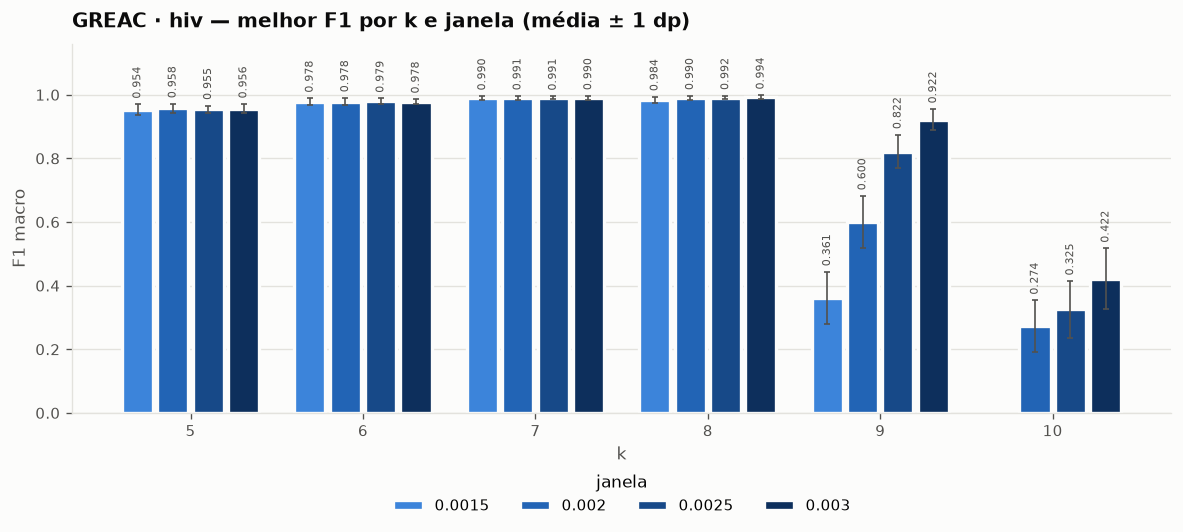

In [12]:
best_t = (ranking.sort_values("f1_score_mean", ascending=False)
          .drop_duplicates(subset=["window", "kmer"]))
colors = window_colors(WINDOWS)

x = np.arange(len(KS))
width = 0.82 / len(WINDOWS)
fig, ax = plt.subplots(figsize=(max(7.0, 0.34 * len(KS) * len(WINDOWS) + 1.8), 4.6))

for i, w in enumerate(WINDOWS):
    sub = best_t[best_t.window == w].set_index("kmer").reindex(KS)
    off = (i - (len(WINDOWS) - 1) / 2) * width
    ax.bar(x + off, sub.f1_score_mean.to_numpy(), width * 0.88, color=colors[w], label=f"{w}",
           edgecolor=SURFACE, linewidth=2,
           yerr=sub.f1_score_std.fillna(0).to_numpy(),
           error_kw=dict(ecolor=INK_2, elinewidth=1, capsize=2))
    # rótulo acima do topo da barra de erro, senão o texto cai em cima da haste
    topo = sub.f1_score_mean + sub.f1_score_std.fillna(0)
    for xi, v, t in zip(x + off, sub.f1_score_mean, topo):
        if not np.isnan(v):
            ax.annotate(f"{v:.3f}", (xi, t), xytext=(0, 5), textcoords="offset points",
                        ha="center", rotation=90, fontsize=6.5, color=INK_2)

ax.set_xticks(x, KS)
ax.set_ylim(0, 1.16)
ax.set_xlabel("k")
ax.set_ylabel("F1 macro")
ax.grid(axis="x", visible=False)
ax.set_title(f"{TITLE} — melhor F1 por k e janela (média ± 1 dp)")
ax.legend(title="janela", loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncols=len(WINDOWS))
fig.tight_layout()
savefig(fig, "best_f1_per_k.png")
plt.show()

## 3. Heatmap threshold × janela, um painel por k

Cor = F1 médio em uma escala de um só tom, compartilhada entre os painéis. A escala começa na mediana
das combinações: abaixo dele tudo fica no tom mais claro (a seta da barra de cor), para a cor
separar as combinações boas em vez de gastar a escala com as que colapsam. Cada célula traz o valor, então a
cor nunca é o único canal. Célula riscada = combinação não executada; texto em cinza = fora do ranking por
cobertura.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


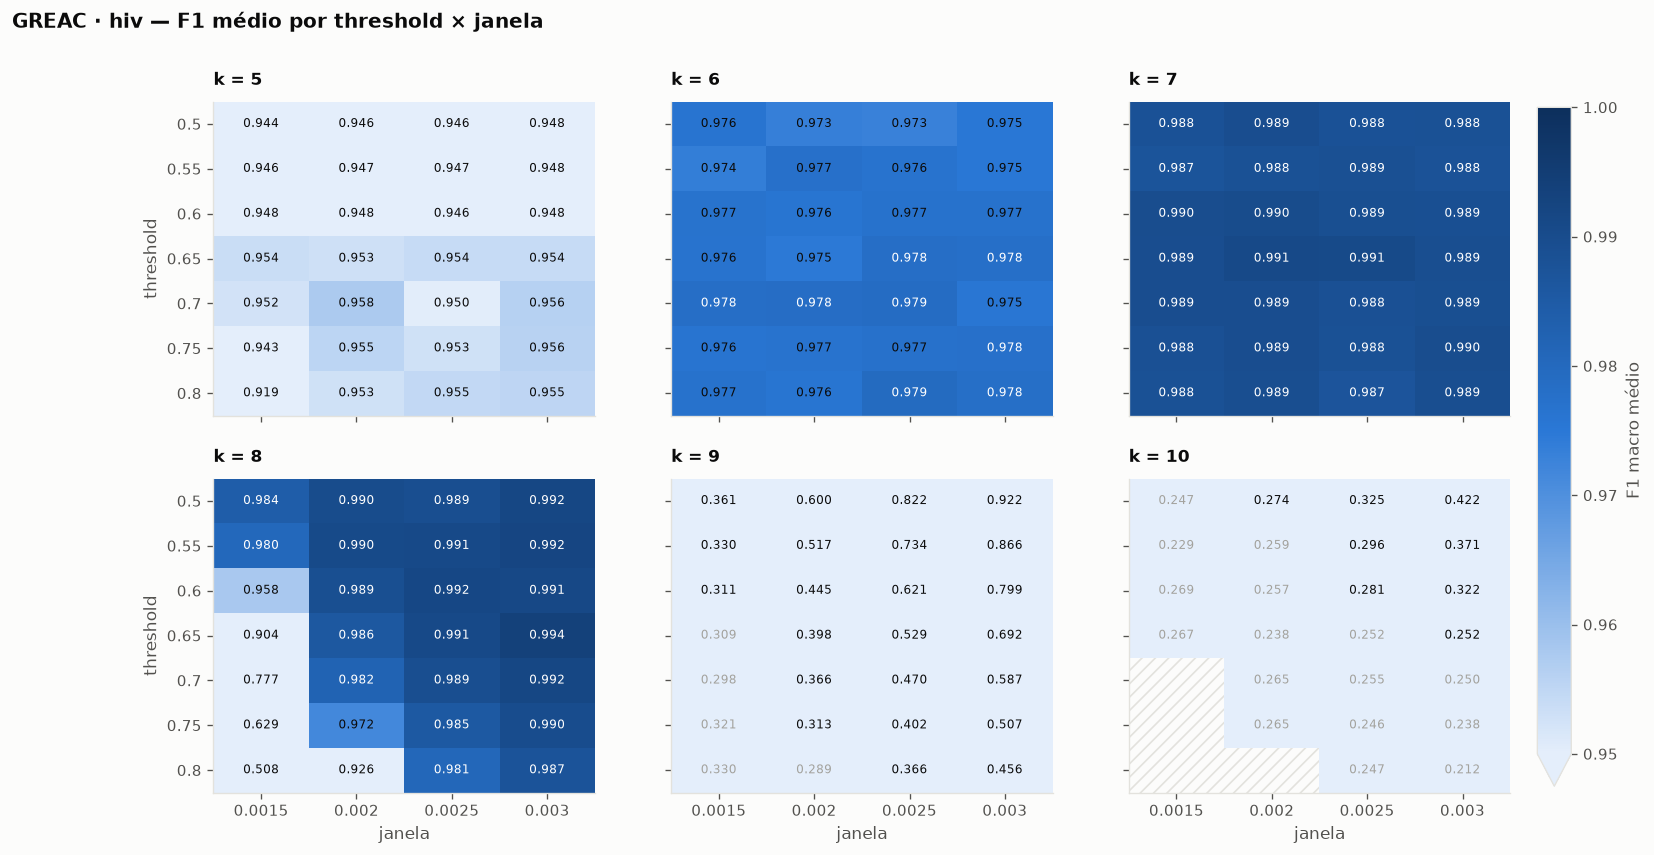

In [13]:
# Escala a partir da mediana (em passos de 0.05): com o colapso em k alto indo
# até ~0.2, uma escala 0–1 (ou mesmo a partir do quartil) pinta a faixa
# 0.94–0.99 inteira do mesmo tom
vmin = min(np.floor(agg.f1_score_mean.median() * 20) / 20, 0.95)
cmap = SEQ.copy()
cmap.set_under(SEQ(0.0))
ncols = min(3, len(KS))
nrows = int(np.ceil(len(KS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(1.0 * len(WINDOWS) * ncols + 2.6, 0.42 * len(THRESHOLDS) * nrows + 1.6),
                         squeeze=False, sharex=True, sharey=True)

for ax, k in zip(axes.flat, KS):
    sub = agg[agg.kmer == k]
    mean_m = sub.pivot(index="threshold", columns="window", values="f1_score_mean").reindex(index=THRESHOLDS, columns=WINDOWS)
    elig_m = sub.pivot(index="threshold", columns="window", values="eligible").reindex(index=THRESHOLDS, columns=WINDOWS)
    im = ax.imshow(mean_m.values, cmap=cmap, vmin=vmin, vmax=1, aspect="auto")
    ax.grid(False)
    for i in range(mean_m.shape[0]):
        for j in range(mean_m.shape[1]):
            v = mean_m.values[i, j]
            if np.isnan(v):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch="///",
                                           edgecolor=GRID, linewidth=0))
                continue
            dark = (v - vmin) / (1 - vmin) > 0.55
            color = MUTED if not elig_m.values[i, j] else ("#ffffff" if dark else INK)
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7, color=color)
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xticks(range(len(WINDOWS)), WINDOWS, rotation=0)
    ax.set_yticks(range(len(THRESHOLDS)), THRESHOLDS)

for ax in axes.flat[len(KS):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("threshold")
for ax in axes[-1]:
    ax.set_xlabel("janela")

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, extend="min", label="F1 macro médio")
fig.suptitle(f"{TITLE} — F1 médio por threshold × janela", x=0.01, ha="left",
             fontsize=12, fontweight="600", color=INK)
savefig(fig, "heatmap_threshold_window.png")
plt.show()

## 4. Cobertura × F1

Cada ponto é uma combinação (médias sobre as repetições). Os pontos à esquerda da linha ficam fora do ranking:
qualquer F1 alto ali vale para uma fração do teste, não para o teste.

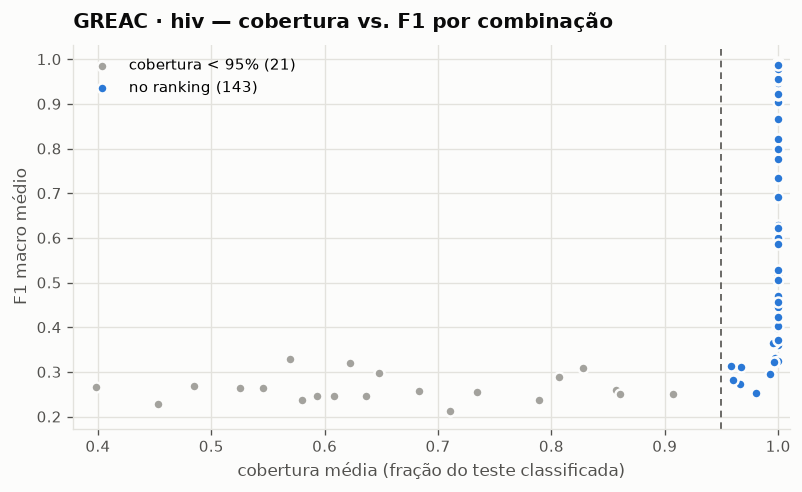

In [14]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
out = agg[~agg.eligible]
ok = agg[agg.eligible]
ax.scatter(out.coverage_mean, out.f1_score_mean, s=36, color=MUTED, edgecolor=SURFACE,
           linewidth=1.5, label=f"cobertura < {MIN_COVERAGE:.0%} ({len(out)})")
ax.scatter(ok.coverage_mean, ok.f1_score_mean, s=36, color=ACCENT, edgecolor=SURFACE,
           linewidth=1.5, label=f"no ranking ({len(ok)})")
ax.axvline(MIN_COVERAGE, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
ax.set_xlabel("cobertura média (fração do teste classificada)")
ax.set_ylabel("F1 macro médio")
ax.set_xlim(min(agg.coverage_mean.min() - 0.02, MIN_COVERAGE - 0.05), 1.01)
ax.set_title(f"{TITLE} — cobertura vs. F1 por combinação")
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "coverage_vs_f1.png")
plt.show()

## 5. Tempo de execução por k

Média sobre todas as combinações e repetições de cada k. Treino = `extractFeaturesTemplate` (extração)
+ `getKmersDistributionPerClass` (ajuste); classificação = `greacClassification` sobre o teste inteiro.
A primeira combinação de cada execução do Julia carrega o tempo de compilação, por isso o desvio
entre repetições da extração tende a ser grande.

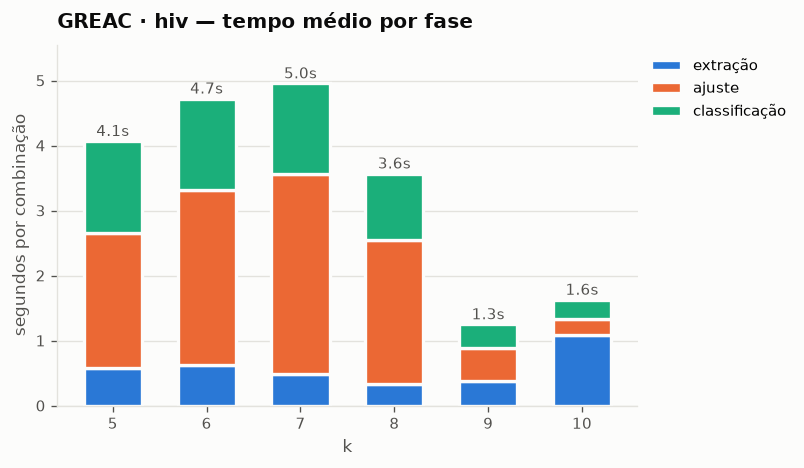

,extract_time,fit_time,classify_time,treino
kmer,,,,
5,0.579,2.081,1.410,2.660
6,0.630,2.692,1.401,3.322
7,0.494,3.071,1.392,3.565
8,0.327,2.222,1.021,2.549
9,0.377,0.506,0.368,0.883
10,1.093,0.244,0.292,1.336


In [15]:
PHASES = [("extract_time", "extração"), ("fit_time", "ajuste"), ("classify_time", "classificação")]
timing = raw.groupby("kmer")[[p for p, _ in PHASES]].mean().reindex(KS)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
bottom = np.zeros(len(KS))
for (col, name), color in zip(PHASES, SERIES):
    bars = ax.bar(KS, timing[col], bottom=bottom, width=0.62, color=color, label=name,
                  edgecolor=SURFACE, linewidth=2)
    bottom += timing[col].to_numpy()
for x, total in zip(KS, bottom):
    ax.annotate(f"{total:.1f}s", (x, total), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)

ax.set_xticks(KS)
ax.set_xlabel("k")
ax.set_ylabel("segundos por combinação")
ax.grid(axis="x", visible=False)
ax.set_title(f"{TITLE} — tempo médio por fase")
ax.set_ylim(0, bottom.max() * 1.12)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
savefig(fig, "time_per_phase.png")
plt.show()

timing.assign(treino=timing.extract_time + timing.fit_time).round(3)

## 6. Distribuição por repetição das melhores combinações

Um ponto por repetição. Caixas que se sobrepõem são combinações que o sweep não consegue separar.

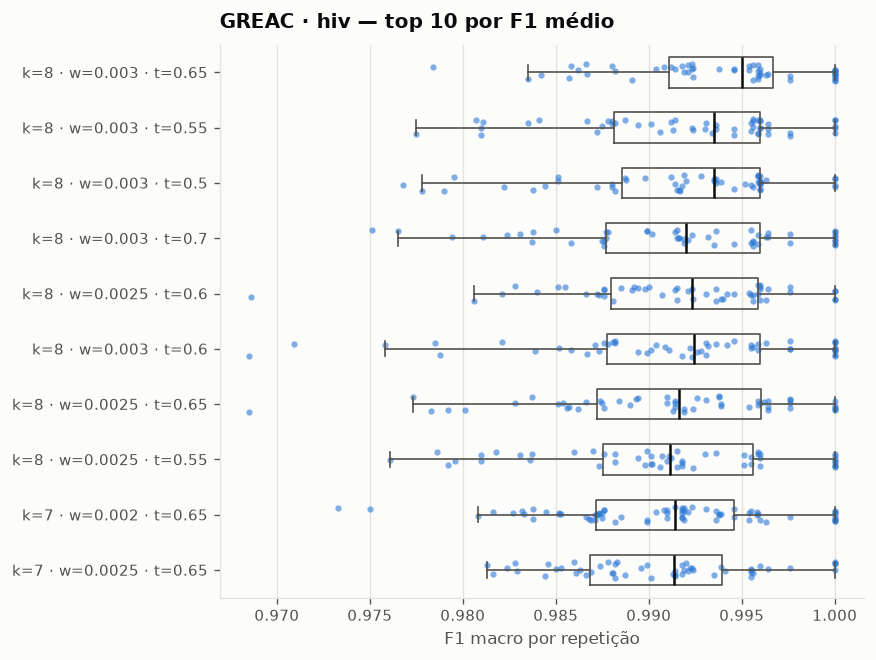

In [16]:
top = ranking.head(TOP_N)
labels, values = [], []
for _, r in top.iterrows():
    sel = raw[(raw.window == r.window) & (raw.threshold == r.threshold) & (raw.kmer == r.kmer)]
    labels.append(f"k={int(r.kmer)} · w={r.window} · t={r.threshold}")
    values.append(sel.f1_score.to_numpy())

fig, ax = plt.subplots(figsize=(7.4, 0.42 * len(top) + 1.4))
pos = np.arange(len(top))[::-1]
ax.boxplot(values, positions=pos, orientation="horizontal", widths=0.55, showfliers=False,
           medianprops=dict(color=INK, linewidth=1.5), boxprops=dict(color=INK_2),
           whiskerprops=dict(color=INK_2), capprops=dict(color=INK_2))
rng = np.random.default_rng(0)
for p, v in zip(pos, values):
    ax.scatter(v, p + rng.uniform(-0.15, 0.15, len(v)), s=14, color=ACCENT, alpha=0.6, linewidth=0)
ax.set_yticks(pos, labels)
ax.set_xlabel("F1 macro por repetição")
ax.grid(axis="y", visible=False)
ax.set_title(f"{TITLE} — top {len(top)} por F1 médio")
fig.tight_layout()
savefig(fig, "top_distribution.png")
plt.show()

## 7. Tabela resumo

In [17]:
agg.sort_values("f1_score_mean", ascending=False).round(6) \
   .to_csv(os.path.join(FIG_DIR, "summary.csv"), index=False)
print("figuras e tabela em", FIG_DIR)
agg.sort_values("f1_score_mean", ascending=False)[SHOW + ["eligible"]].round(4)

figuras e tabela em figs/greac/hiv


,window,threshold,kmer,n,f1_score_mean,f1_score_std,precision_mean,recall_mean,coverage_mean,train_time_mean,classify_time_mean,eligible
143,0.0030,0.65,8,52,0.9936,0.0052,0.9925,0.9950,1.0000,3.0224,1.4393,True
131,0.0030,0.55,8,52,0.9921,0.0057,0.9908,0.9938,1.0000,3.1055,1.4284,True
125,0.0030,0.50,8,52,0.9918,0.0058,0.9900,0.9938,1.0000,3.0160,1.4600,True
149,0.0030,0.70,8,52,0.9917,0.0064,0.9901,0.9934,1.0000,3.2689,1.4581,True
95,0.0025,0.60,8,52,0.9916,0.0058,0.9901,0.9934,1.0000,2.9844,1.3208,True
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0025,0.75,10,20,0.2456,0.0612,0.2906,0.2872,0.6368,1.1925,0.1614,False
157,0.0030,0.75,10,45,0.2377,0.0732,0.3075,0.2829,0.7887,1.3080,0.2510,False
62,0.0020,0.65,10,31,0.2377,0.0721,0.3010,0.2790,0.5803,1.2286,0.1348,False
11,0.0015,0.55,10,30,0.2291,0.0862,0.2779,0.2696,0.4529,1.2256,0.1482,False
